In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
#%pip install --upgrade pip

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

sns.set_theme(style='darkgrid')
print('All libraries loaded ✓')

All libraries loaded ✓


In [4]:
results      = pd.read_csv('results.csv')
drivers      = pd.read_csv('drivers.csv')
constructors = pd.read_csv('constructors.csv')
races        = pd.read_csv('races.csv')
quali = pd.read_csv('qualifying.csv')

print('results shape:     ', results.shape)
print('drivers shape:     ', drivers.shape)
print('constructors shape:', constructors.shape)
print('races shape:       ', races.shape)
print('Qualifying shape:',quali.shape)

results shape:      (26759, 18)
drivers shape:      (861, 9)
constructors shape: (212, 5)
races shape:        (1125, 18)
Qualifying shape: (10494, 9)


In [5]:
print(results.columns.tolist())
print()
results.head()

['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']



,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [6]:
print("Missing values:")
print(results.isnull().sum())
print("Data types:",results.dtypes)

Missing values:
resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64
Data types: resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object


In [7]:
print(results['positionText'].unique())

['1' '2' '3' '4' '5' '6' '7' '8' 'R' 'D' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' 'N' 'W' 'F' 'E' '22' '23' '24' '25' '26'
 '27' '28' '29' '30' '31' '32' '33']


In [8]:
results['in_points'] = results['positionText'].apply (
    lambda x: 1 if x.isdigit() and int (x) <= 10 else 0
)

print(results['in_points'].value_counts())
print('Point finishes %: ', round (results['in_points'].mean()*100 , 1))

in_points
0    15777
1    10982
Name: count, dtype: int64
Point finishes %:  41.0


In [9]:
results['grid'] = results['grid'].replace(0, np.nan)
results['grid'] = results['grid'].fillna(results['grid'].median())
print("Grid cleaned. Zeros remaining: ", (results['grid']==0).sum())

Grid cleaned. Zeros remaining:  0


In [10]:
df = results.merge(constructors[['constructorId','name']], on='constructorId',how='left')
df = df.rename(columns={'name':'constructor_name'})

df = df.merge(races[['raceId', 'year', 'round']], on='raceId', how='left')

print("Merged data frame shape: ",df.shape)
print(df[['grid','in_points','constructor_name','year','round']].head())

Merged data frame shape:  (26759, 22)
   grid  in_points constructor_name  year  round
0   1.0          1          McLaren  2008      1
1   5.0          1       BMW Sauber  2008      1
2   7.0          1         Williams  2008      1
3  11.0          1          Renault  2008      1
4   3.0          1          McLaren  2008      1


In [11]:
le = LabelEncoder()
df['constructor_encoded'] = le.fit_transform(df['constructor_name'].fillna('Unknown'))
print('Constructor encoding done. Sample:')
print(df[['constructor_name','constructor_encoded']].drop_duplicates().head(8))

Constructor encoding done. Sample:
   constructor_name  constructor_encoded
0           McLaren                  134
1        BMW Sauber                   17
2          Williams                  208
3           Renault                  167
6        Toro Rosso                  197
7           Ferrari                   73
9            Toyota                  198
10      Super Aguri                  187


/var/folders/2n/76vkqj0s60zbr3hmw1vjl77m0000gn/T/ipykernel_43300/2749737250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='in_points', y='grid', palette=['#e10600','#15003c'])


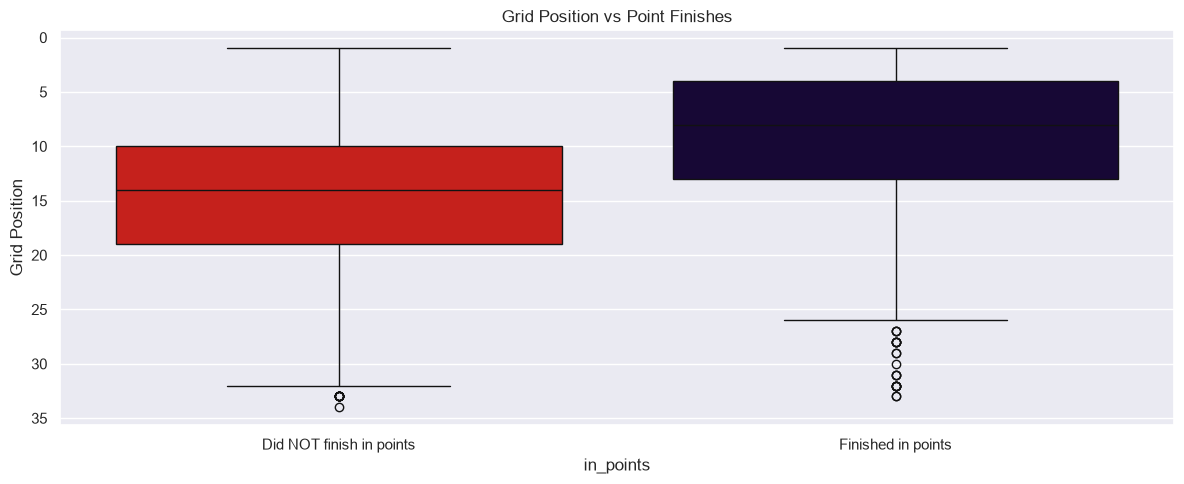

In [12]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='in_points', y='grid', palette=['#e10600','#15003c'])
plt.xticks([0,1],['Did NOT finish in points','Finished in points'])
plt.ylabel('Grid Position')
plt.title('Grid Position vs Point Finishes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('grid_vs_points.png', dpi=300)
plt.show()



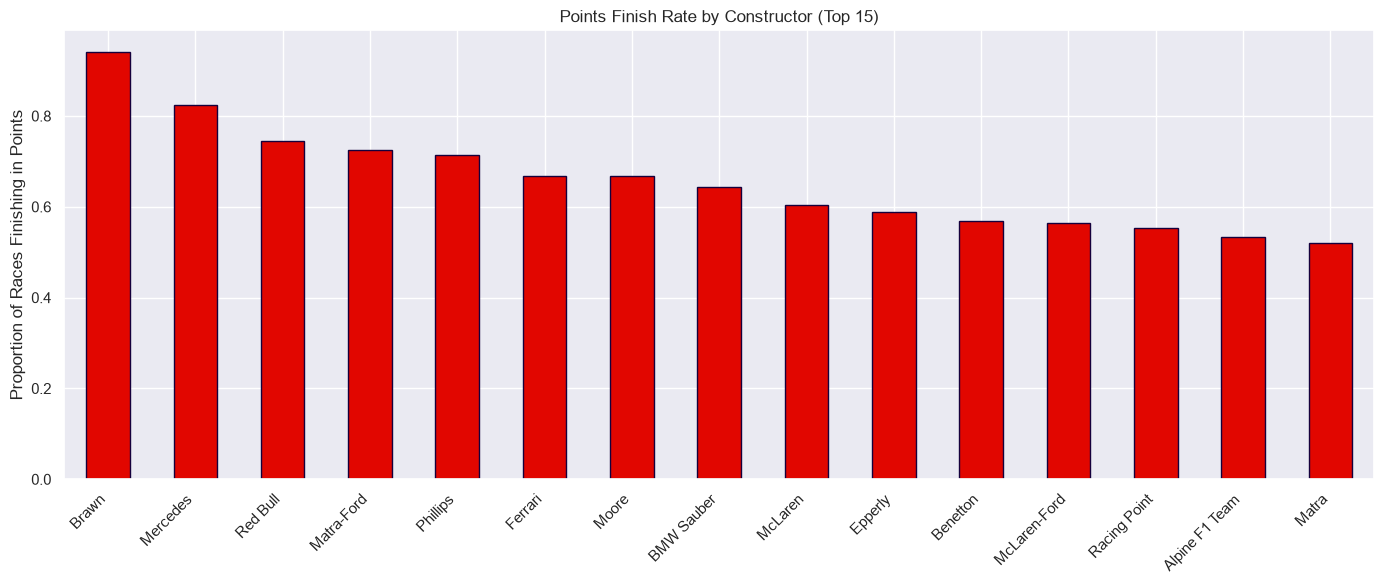

Top 5 constructors by points finish rate:
constructor_name
Brawn         0.941176
Mercedes      0.825153
Red Bull      0.744924
Matra-Ford    0.725000
Phillips      0.714286
Name: in_points, dtype: float64


In [13]:
constructor_pts = df.groupby('constructor_name')['in_points'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
constructor_pts.head(15).plot(kind='bar', color='#e10600', edgecolor='#15003c')
plt.title('Points Finish Rate by Constructor (Top 15)')
plt.ylabel('Proportion of Races Finishing in Points')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('constructor_points_rate.png', dpi=150)
plt.show()

print('Top 5 constructors by points finish rate:')
print(constructor_pts.head())

In [14]:
%pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
%pip install fastf1

Note: you may need to restart the kernel to use updated packages.


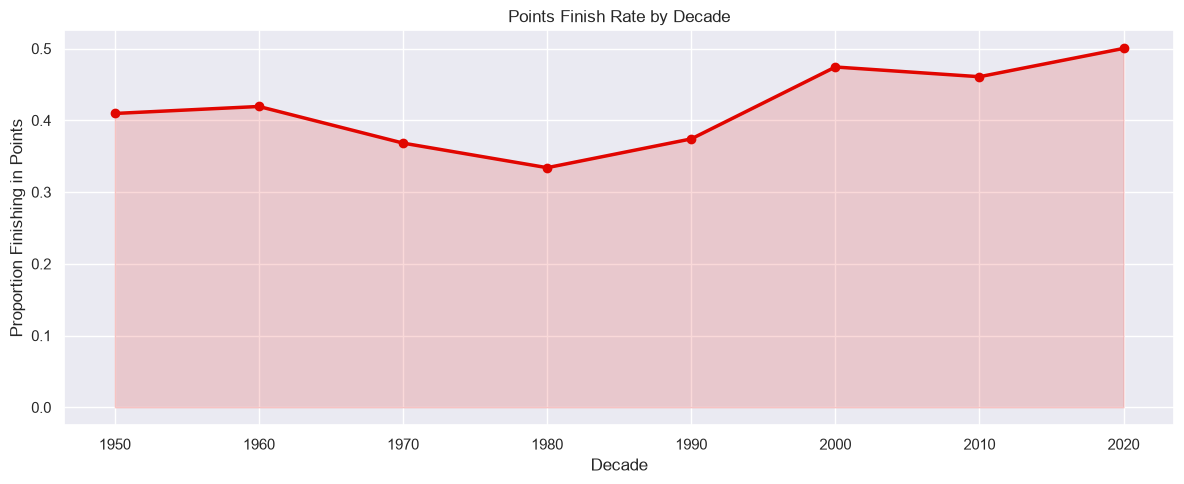

In [16]:
df['decade'] = (df['year'] // 10) * 10
decade_trend = df.groupby('decade')['in_points'].mean()

plt.figure(figsize=(12, 5))
plt.plot(decade_trend.index, decade_trend.values,
         marker='o', color='#e10600', linewidth=2.5)
plt.fill_between(decade_trend.index, decade_trend.values,
                 alpha=0.15, color='#e10600')
plt.title('Points Finish Rate by Decade')
plt.ylabel('Proportion Finishing in Points')
plt.xlabel('Decade')
plt.tight_layout()
plt.savefig('decade_trend.png', dpi=300)
plt.show()

In [17]:
import fastf1

In [18]:
fastf1.Cache.enable_cache('f1_cache')

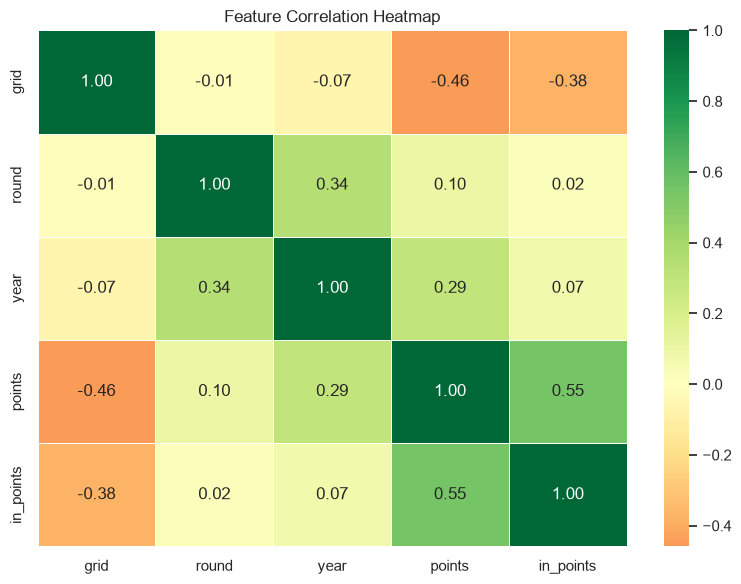

In [19]:
features_for_corr = df[['grid','round','year','points','in_points']].copy()

plt.figure(figsize=(8,6))
sns.heatmap(features_for_corr.corr(), annot=True, cmap='RdYlGn', fmt=".2f",center=0, linewidths=0.5,)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

In [20]:
features = ['grid', 'round', 'year', 'constructor_encoded']
target = 'in_points'

ml_df = df[features + [target]].dropna()
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set size: ', X_train.shape)
print('Test set size: ', X_test.shape)
print('Points finish rate in training set: ', round(y_train.mean(), 3))


Training set size:  (21407, 4)
Test set size:  (5352, 4)
Points finish rate in training set:  0.41


In [21]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_peds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print('===Logistic Regression===')
print(classification_report(y_test, lr_peds,target_names=['No points','In points']))
print('ROC AUC Score: ', round(roc_auc_score(y_test, lr_proba), 4))



===Logistic Regression===
              precision    recall  f1-score   support

   No points       0.71      0.80      0.75      3149
   In points       0.65      0.53      0.58      2203

    accuracy                           0.69      5352
   macro avg       0.68      0.66      0.67      5352
weighted avg       0.68      0.69      0.68      5352

ROC AUC Score:  0.7146


In [22]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train,y_train)

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

print('===Logistic Regression===')
print(classification_report(y_test,rf_preds,target_names=['No points','In points']))
print('ROC AUC Score: ',round(roc_auc_score(y_test,rf_proba),4))

===Logistic Regression===
              precision    recall  f1-score   support

   No points       0.70      0.75      0.73      3149
   In points       0.61      0.55      0.58      2203

    accuracy                           0.67      5352
   macro avg       0.65      0.65      0.65      5352
weighted avg       0.66      0.67      0.66      5352

ROC AUC Score:  0.7346


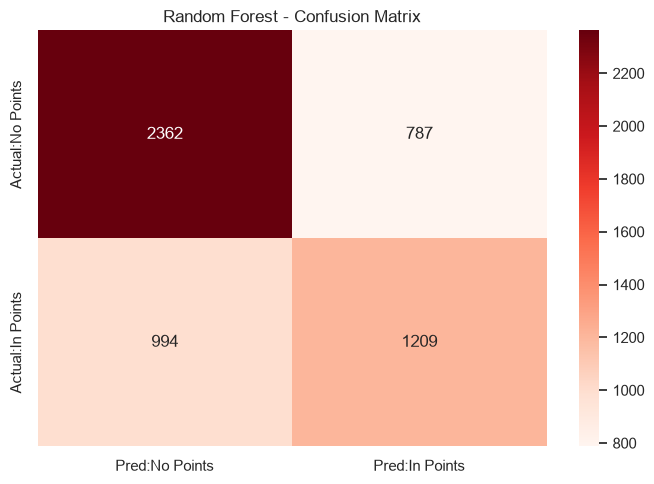

In [23]:
cm = confusion_matrix(y_test,rf_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=['Pred:No Points','Pred:In Points'],yticklabels=['Actual:No Points','Actual:In Points'])
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png',dpi=300)
plt.show()


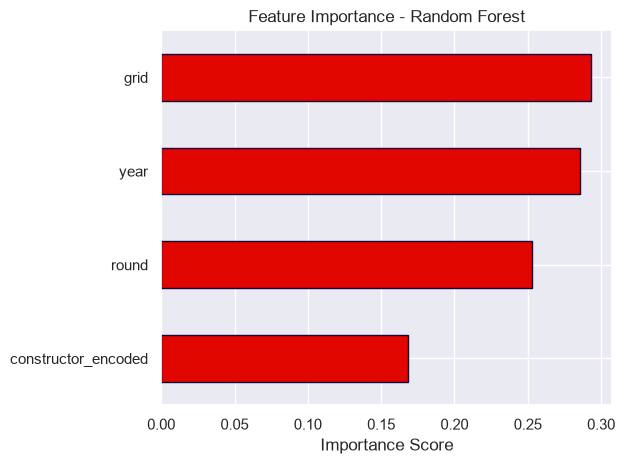

grid                   0.293077
year                   0.285628
round                  0.252750
constructor_encoded    0.168545
dtype: float64


In [24]:
importances = pd.Series(rf_model.feature_importances_,index = features)
importances = importances.sort_values(ascending=True)

plt.Figure(figsize=(8,5))
importances.plot(kind='barh',color='#e10600',edgecolor='#15003c')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_rf.png',dpi = 300)
plt.show()

print(importances.sort_values(ascending=False))

In [25]:
summary = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[
        round((lr_peds == y_test).mean(),4),
        round((rf_preds == y_test).mean(),4)
    ],
    'ROC-AUC':[
        round(roc_auc_score(y_test,lr_proba),4),
        round(roc_auc_score(y_test,rf_proba),4)
    ]
})

print(summary.to_string(index=False))

              Model  Accuracy  ROC-AUC
Logistic Regression    0.6876   0.7146
      Random Forest    0.6672   0.7346


In [26]:
mercedes_encoded = df[df['constructor_name']== 
                     'Mercedes']['constructor_encoded'].iloc[0]
print('Mercedes encoded as: ',mercedes_encoded)

scenario = pd.DataFrame({
    'grid':[6],
    'round':[8],
    'year':[2021],
    'constructor_encoded':[mercedes_encoded]
})
prob = rf_model.predict_proba(scenario)[0][1]
pred = rf_model.predict(scenario)[0]

print(f'Probability of scoring points: {prob:.1%}')
print(f'Prediction: {"In Points " if pred == 1 else 'No points'}')



Mercedes encoded as:  139
Probability of scoring points: 92.0%
Prediction: In Points 


In [27]:
print(quali.columns.to_list)
print()
print(quali.head())

<bound method IndexOpsMixin.tolist of Index(['qualifyId', 'raceId', 'driverId', 'constructorId', 'number',
       'position', 'q1', 'q2', 'q3'],
      dtype='object')>

   qualifyId  raceId  driverId  constructorId  number  position        q1  \
0          1      18         1              1      22         1  1:26.572   
1          2      18         9              2       4         2  1:26.103   
2          3      18         5              1      23         3  1:25.664   
3          4      18        13              6       2         4  1:25.994   
4          5      18         2              2       3         5  1:25.960   

         q2        q3  
0  1:25.187  1:26.714  
1  1:25.315  1:26.869  
2  1:25.452  1:27.079  
3  1:25.691  1:27.178  
4  1:25.518  1:27.236  


In [28]:
print('Missing values:')
print(quali.isnull().sum())

Missing values:
qualifyId         0
raceId            0
driverId          0
constructorId     0
number            0
position          0
q1                0
q2               22
q3               46
dtype: int64


In [29]:
def time_to_sec(t):
    if pd.isna(t) or str(t).strip() =='\\N' or str(t).strip == '':
        return np.nan
    try:
        parts = str(t).strip().split(':')
        return int (parts[0])* 60 + float (parts[1])
    except:
        return np.nan
    
quali['q1_seconds'] = quali['q1'].apply(time_to_sec)
quali['q2_seconds'] = quali['q2'].apply(time_to_sec)
quali['q3_seconds'] = quali['q3'].apply(time_to_sec)

print('Sample conversion:')
sample = quali[quali['q1_seconds'].notna()][['q1','q1_seconds']].head(5)
print(sample.to_string(index=False))
print()
print('q1_sec missing:', quali['q1_seconds'].isna().sum())
print('q2_sec missing:', quali['q2_seconds'].isna().sum())
print('q3_sec missing:', quali['q3_seconds'].isna().sum())


Sample conversion:
      q1  q1_seconds
1:26.572      86.572
1:26.103      86.103
1:25.664      85.664
1:25.994      85.994
1:25.960      85.960

q1_sec missing: 156
q2_sec missing: 4647
q3_sec missing: 6865


In [30]:
print('Drivers with Q2 time:',quali['q2'].notna().sum())
print('Drivers with Q3 time:',quali['q3'].notna().sum())

Drivers with Q2 time: 10472
Drivers with Q3 time: 10448


In [31]:
quali['best_lap'] = (
    quali['q3_seconds']
    .fillna(quali['q2_seconds'])
    .fillna(quali['q1_seconds'])
)
print('Drivers with best laptime:',quali['best_lap'].notna().sum())
print('Drivers missing any laptime:',quali['best_lap'].isna().sum())
print()
print('Best lap time stats in SECONDS:')
print(quali['best_lap'].describe().round(4))

Drivers with best laptime: 10338
Drivers missing any laptime: 156

Best lap time stats in SECONDS:
count    10338.0000
mean        88.3276
std         15.3722
min         53.3770
25%         78.7715
50%         87.0645
75%         95.8190
max       1002.6400
Name: best_lap, dtype: float64


In [32]:
# Pole time = the fastest best_lap in each race
pole_times = (quali
              .groupby('raceId')['best_lap']
              .min()
              .reset_index())
pole_times.columns = ['raceId', 'pole_time_sec']

# Merge pole time back into qualifying
quali = quali.merge(pole_times, on='raceId', how='left')

# Delta = driver's best lap minus pole time (in seconds)
quali['delta'] = quali['best_lap'] - quali['pole_time_sec']

print('Delta to pole stats (seconds):')
print(quali['delta'].describe().round(3))
print()
# Pole sitter should always have delta = 0
print('Rows where delta = 0 (pole sitters):', (quali['delta'] == 0).sum())
print()
print(quali[['raceId','driverId','position','best_lap',
                   'pole_time_sec','delta']].head(10))

Delta to pole stats (seconds):
count    10338.000
mean         2.381
std          9.327
min          0.000
25%          0.828
50%          1.623
75%          2.724
max        904.617
Name: delta, dtype: float64

Rows where delta = 0 (pole sitters): 494

   raceId  driverId  position  best_lap  pole_time_sec  delta
0      18         1         1    86.714         85.842  0.872
1      18         9         2    86.869         85.842  1.027
2      18         5         3    87.079         85.842  1.237
3      18        13         4    87.178         85.842  1.336
4      18         2         5    87.236         85.842  1.394
5      18        15         6    88.527         85.842  2.685
6      18         3         7    88.687         85.842  2.845
7      18        14         8    89.041         85.842  3.199
8      18        10         9    89.593         85.842  3.751
9      18        20        10    85.842         85.842  0.000


In [33]:
k_quali = quali[[
    'raceId','driverId','position','best_lap','delta'
]].copy()
k_quali = k_quali.rename(columns={'position':'quali_position'})

print('Qualifying table ready for merge:')
print('Shape:',k_quali.shape)
print(k_quali.head())

Qualifying table ready for merge:
Shape: (10494, 5)
   raceId  driverId  quali_position  best_lap  delta
0      18         1               1    86.714  0.872
1      18         9               2    86.869  1.027
2      18         5               3    87.079  1.237
3      18        13               4    87.178  1.336
4      18         2               5    87.236  1.394


In [34]:
df = df.merge(
    k_quali,
    on=['raceId', 'driverId'],
    how='left'
    )

print('Shape after merging qualifying data:', df.shape)
print()
print('Rows with delta:', df['delta'].notna().sum())
print('Rows without delta:', df['delta'].isna().sum())
print()

sample_race = df[df['year'] == 2023][
    ['raceId','grid','quali_position','delta','in_points']
].dropna().head(10)
print(sample_race.to_string(index=False))

Shape after merging qualifying data: (26759, 27)

Rows with delta: 10338
Rows without delta: 16421

 raceId  grid  quali_position  delta  in_points
   1098   1.0             1.0  0.000          1
   1098   2.0             2.0  0.138          1
   1098   5.0             5.0  0.628          1
   1098   4.0             4.0  0.446          1
   1098   7.0             7.0  0.676          1
   1098   8.0             8.0  1.128          1
   1098   6.0             6.0  0.632          1
   1098  12.0            12.0  1.735          1
   1098  20.0            20.0  2.473          1
   1098  15.0            15.0  1.753          1


In [37]:
seasons = list(range(2018,2024))

test = fastf1.get_session(2023, 1,'Q')
test.load(laps = False,telemetry=False)

print('FastF1 connection OK')
print('Test session:',test.event['EventName'])
print('Seasons to enrich:',seasons)

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']


FastF1 connection OK
Test session: Bahrain Grand Prix
Seasons to enrich: [2018, 2019, 2020, 2021, 2022, 2023]


In [36]:
quali_records = []

for year in seasons:
    schedule = fastf1.get_event_schedule(year,include_testing=False)
    for _,event in schedule.iterrows():
        round_num = event['RoundNumber']
        try:
            q = fastf1.get_session(year, round_num, 'Q')
            q.load(laps=True,telemetry=False)

            best =(q.laps
                   .groupby('Driver')['LapTime']
                   .min()
                   .reset_index())
            best.columns = ['driver_dode','Best_Lap_Time']
            pole_time = best['Best_Lap_Time'].min()

            best['ff1_delta'] = (
                best['Best_Lap_Time'] - pole_time
            ).dt.total_seconds()
            best['year'] = year
            best['round'] = round_num

            quali_records.append(best[['driver_dode','year','round','ff1_delta']])

        except Exception as e:
            print(f'Error processing {year} Round {round_num}: {e}')
            continue

ff1_quali = pd.concat(quali_records, ignore_index=True)
print('FastF1 Qualifying Records:', len(ff1_quali))
print(ff1_quali.head())

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '7', '5', '33', '3', '20', '8', '27', '55', '77', '14', '2', '11', '18', '31', '28', '9', '16', '35', '10']
core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using 

FastF1 Qualifying Records: 2491
  driver_dode  year  round  ff1_delta
0         ALO  2018      1      2.433
1         BOT  2018      1      0.925
2         ERI  2018      1      3.392
3         GAS  2018      1      4.131
4         GRO  2018      1      2.175


In [ ]:
ff1_race_records = []